Tickers: 503. Example: ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'META', 'AVGO', 'GOOGL', 'GOOG', 'TSLA', 'BRK-B']
Fetching dividend_yield snapshot…
  50/503
  100/503
  150/503
  200/503
  250/503
  300/503
  350/503
  400/503
  450/503
  500/503
Payers: 407 | Non-payers: 96
Batch 1/26 (20 tickers) att 1
Batch 2/26 (20 tickers) att 1
Batch 3/26 (20 tickers) att 1
Batch 4/26 (20 tickers) att 1
Batch 5/26 (20 tickers) att 1
Batch 6/26 (20 tickers) att 1
Batch 7/26 (20 tickers) att 1
Batch 8/26 (20 tickers) att 1
Batch 9/26 (20 tickers) att 1
Batch 10/26 (20 tickers) att 1
Batch 11/26 (20 tickers) att 1
Batch 12/26 (20 tickers) att 1
Batch 13/26 (20 tickers) att 1
Batch 14/26 (20 tickers) att 1
Batch 15/26 (20 tickers) att 1
Batch 16/26 (20 tickers) att 1
Batch 17/26 (20 tickers) att 1
Batch 18/26 (20 tickers) att 1
Batch 19/26 (20 tickers) att 1
Batch 20/26 (20 tickers) att 1
Batch 21/26 (20 tickers) att 1
Batch 22/26 (20 tickers) att 1
Batch 23/26 (20 tickers) att 1
Batch 24/26 (20 tickers) att

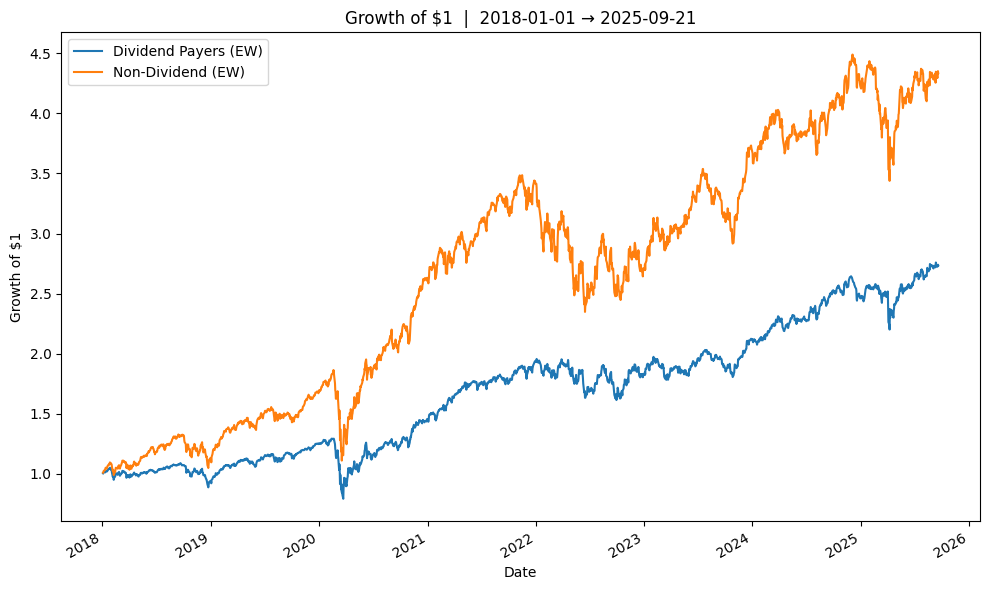

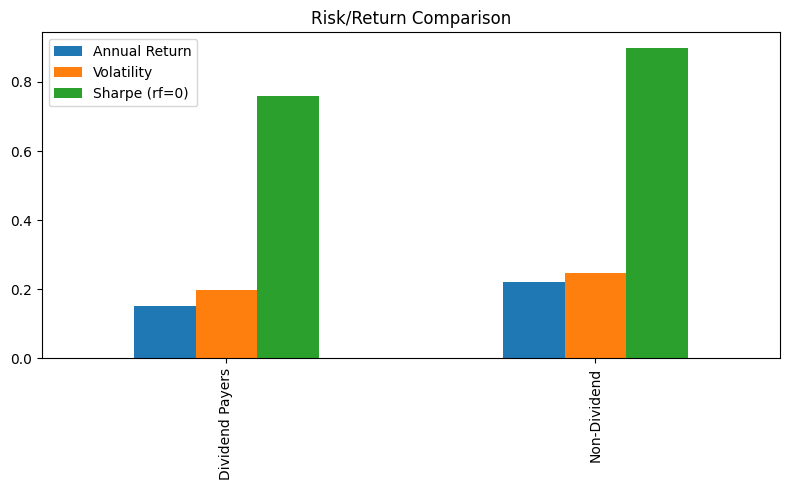


Note: Groups are formed using CURRENT dividend yields (snapshot). For a stricter study, re-form groups each December using that year's yields, then evaluate next-year returns.


In [1]:
# ============================================
# Dividend Payers vs NON-Dividend Stocks (S&P 500, 2018–today)
# Equal-weight portfolios by current dividend_yield (yfinance)
# ============================================

import warnings, time, requests
warnings.filterwarnings("ignore")

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date

# -------- Config (tweak if needed) --------
START_DATE   = "2018-01-01"
END_DATE     = None            # None = today
BATCH_SIZE   = 20              # small to avoid throttling
MIN_COVERAGE = 0.70            # require ≥70% price history
MAX_RETRIES  = 4
RETRY_SLEEP  = 2.5
VERBOSE      = True

# -------- Helpers --------
def fix_yf_symbol(s: str) -> str:
    return s.replace(".", "-").strip()

def get_sp500_tickers():
    """Prefer Slickcharts (with UA header); fallback to Wikipedia."""
    hdr = {"User-Agent":"Mozilla/5.0"}
    try:
        html = requests.get("https://slickcharts.com/sp500", headers=hdr, timeout=30).text
        tbl = pd.read_html(html)[0]
        syms = tbl["Symbol"].astype(str).tolist()
    except Exception as e:
        if VERBOSE: print("Slickcharts failed, trying Wikipedia:", e)
        tbl = pd.read_html("https://en.wikipedia.org/wiki/List_of_S%26P_500_companies")[0]
        syms = tbl["Symbol"].astype(str).tolist()
    out, seen = [], set()
    for t in syms:
        y = fix_yf_symbol(t)
        if y and y not in seen:
            out.append(y); seen.add(y)
    return out

def robust_download(tickers, start, end=None, batch_size=20, max_retries=4, sleep_s=2.0):
    """Download adjusted CLOSE (auto_adjust=True) in small batches, with salvage per-ticker."""
    frames = []
    n = len(tickers); total = int(np.ceil(n/batch_size))
    for i in range(0, n, batch_size):
        batch = tickers[i:i+batch_size]
        df = None
        for att in range(1, max_retries+1):
            try:
                if VERBOSE: print(f"Batch {i//batch_size+1}/{total} ({len(batch)} tickers) att {att}")
                tmp = yf.download(batch, start=start, end=end, auto_adjust=True,
                                  progress=False, threads=False)
                if tmp is None or tmp.empty:
                    raise ValueError("empty batch")
                # Normalize to wide Close matrix
                if isinstance(tmp.columns, pd.MultiIndex):
                    if "Close" in tmp.columns.levels[0]:
                        close = tmp["Close"].copy()
                    else:
                        close = tmp.xs(tmp.columns.levels[0][-1], axis=1, level=0)
                else:
                    close = tmp
                if isinstance(close.columns, pd.MultiIndex):
                    close.columns = [c[-1] for c in close.columns]
                frames.append(close); df = close; break
            except Exception as e:
                if VERBOSE: print("  batch error:", e)
                time.sleep(sleep_s)
        if df is None:
            if VERBOSE: print("  Salvaging one-by-one…")
            cols = []
            for t in batch:
                got = False
                for a in range(1, max_retries+1):
                    try:
                        h = yf.Ticker(t).history(start=start, end=end, auto_adjust=True)
                        if h is not None and not h.empty:
                            cols.append(h["Close"].rename(t)); got = True; break
                    except Exception:
                        time.sleep(0.8)
                if not got and VERBOSE:
                    print(f"    {t}: no data")
            if cols:
                frames.append(pd.concat(cols, axis=1))
    if not frames:
        return pd.DataFrame()
    out = pd.concat(frames, axis=1)
    out = out.loc[:, ~out.columns.duplicated()]
    return out.sort_index()

def get_dividend_yield(t: str) -> float:
    """Use fast_info.dividend_yield (decimal) then fallback to info['dividendYield']."""
    try:
        ti = yf.Ticker(t)
        fi = getattr(ti, "fast_info", None)
        if fi is not None:
            val = getattr(fi, "dividend_yield", None)
            if val is not None and np.isfinite(val):
                return float(val)
        inf = ti.info
        val = inf.get("dividendYield", 0.0) or 0.0
        return float(val)
    except Exception:
        return 0.0

def max_drawdown(r: pd.Series) -> float:
    curve = (1 + r).cumprod()
    return float((curve/curve.cummax() - 1).min()) if len(curve) else np.nan

def perf_metrics(r: pd.Series):
    ann = float(r.mean() * 252)
    vol = float(r.std() * np.sqrt(252))
    shp = float(ann/vol) if vol != 0 else np.nan  # rf=0 for simplicity
    mdd = max_drawdown(r)
    tot = float((1 + r).prod() - 1)
    return ann, vol, shp, mdd, tot

# -------- 1) Universe --------
tickers = get_sp500_tickers()
print(f"Tickers: {len(tickers)}. Example:", tickers[:10])

# -------- 2) Classify by CURRENT dividend_yield (snapshot) --------
print("Fetching dividend_yield snapshot…")
div_y = {}
for i, t in enumerate(tickers, 1):
    div_y[t] = get_dividend_yield(t)
    if VERBOSE and i % 50 == 0:
        print(f"  {i}/{len(tickers)}")
div_y = pd.Series(div_y).replace([np.inf, -np.inf], np.nan).fillna(0.0)

payers    = sorted([t for t, y in div_y.items() if y > 0.0])   # dividend payers
nonpayers = sorted([t for t, y in div_y.items() if y == 0.0])  # true zero-yield

print(f"Payers: {len(payers)} | Non-payers: {len(nonpayers)}")

# -------- 3) Prices (robust, small batches) --------
print("Downloading adjusted CLOSE prices…")
prices = robust_download(tickers, START_DATE, END_DATE,
                         batch_size=BATCH_SIZE, max_retries=MAX_RETRIES, sleep_s=RETRY_SLEEP)
if prices.empty:
    raise RuntimeError("No prices downloaded. Check network/VPN and re-run.")

rets = prices.pct_change().dropna(how="all")

# Keep stocks with sufficient data
min_obs = int(MIN_COVERAGE * len(rets))
good = [c for c in rets.columns if rets[c].count() >= min_obs]
rets = rets[good]

# Intersect groups with available data
payers    = [t for t in payers    if t in rets.columns]
nonpayers = [t for t in nonpayers if t in rets.columns]
print(f"Usable tickers — Payers: {len(payers)}, Non-payers: {len(nonpayers)}")

# If non-payers too few, suggest loosening rule (but still proceed if non-empty)
if len(nonpayers) == 0 or len(payers) == 0:
    raise RuntimeError("One of the groups is empty after filtering. "
                       "Try later START_DATE (e.g., '2020-01-01') or lower MIN_COVERAGE (e.g., 0.60).")

# -------- 4) Equal-weight portfolios --------
payers_ret    = rets[payers].mean(axis=1)
nonpayers_ret = rets[nonpayers].mean(axis=1)

idx = payers_ret.index.intersection(nonpayers_ret.index)
payers_ret    = payers_ret.reindex(idx)
nonpayers_ret = nonpayers_ret.reindex(idx)

# -------- 5) Metrics --------
m_payers    = perf_metrics(payers_ret)
m_nonpayers = perf_metrics(nonpayers_ret)

results = pd.DataFrame(
    {"Dividend Payers": m_payers, "Non-Dividend": m_nonpayers},
    index=["Annual Return","Volatility","Sharpe (rf=0)","Max Drawdown","Total Return"]
)

# Pretty print
def fmt(x, kind):
    if pd.isna(x): return "—"
    return f"{x:.2%}" if kind in ("ret","vol","dd","total") else f"{x:.2f}"

pretty = pd.DataFrame(index=results.index, columns=results.columns)
pretty.loc["Annual Return"] = results.loc["Annual Return"].map(lambda v: fmt(v,"ret"))
pretty.loc["Volatility"]    = results.loc["Volatility"].map(lambda v: fmt(v,"vol"))
pretty.loc["Sharpe (rf=0)"] = results.loc["Sharpe (rf=0)"].map(lambda v: fmt(v,"sharpe"))
pretty.loc["Max Drawdown"]  = results.loc["Max Drawdown"].map(lambda v: fmt(v,"dd"))
pretty.loc["Total Return"]  = results.loc["Total Return"].map(lambda v: fmt(v,"total"))

print("\n===== RESULTS: Dividend Payers vs Non-Dividend =====")
print(pretty)

# -------- 6) Plot: growth of $1 --------
plt.figure(figsize=(10,6))
(1 + payers_ret).cumprod().plot(label="Dividend Payers (EW)")
(1 + nonpayers_ret).cumprod().plot(label="Non-Dividend (EW)")
title_end = date.today() if END_DATE is None else END_DATE
plt.title(f"Growth of $1  |  {START_DATE} → {title_end}")
plt.xlabel("Date"); plt.ylabel("Growth of $1"); plt.legend(); plt.tight_layout(); plt.show()

# -------- 7) Bar chart (risk/return) --------
row_ret, row_vol, row_shp = "Annual Return","Volatility","Sharpe (rf=0)"
bar = pd.DataFrame({
    "Annual Return":[float(results.at[row_ret,"Dividend Payers"]), float(results.at[row_ret,"Non-Dividend"])],
    "Volatility":[float(results.at[row_vol,"Dividend Payers"]), float(results.at[row_vol,"Non-Dividend"])],
    "Sharpe (rf=0)":[float(results.at[row_shp,"Dividend Payers"]), float(results.at[row_shp,"Non-Dividend"])],
}, index=["Dividend Payers","Non-Dividend"])
bar.plot(kind="bar", figsize=(8,5))
plt.title("Risk/Return Comparison"); plt.xlabel(""); plt.tight_layout(); plt.show()

print("\nNote: Groups are formed using CURRENT dividend yields (snapshot). For a stricter study, re-form groups each December using that year's yields, then evaluate next-year returns.")
